In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import tensorflow as tf

2025-05-05 14:53:45.593621: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-05 14:53:45.593756: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-05 14:53:45.784754: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Input, Dropout, GlobalAveragePooling2D, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D
from keras.layers import Bidirectional, LSTM, SimpleRNN
from keras.models import Model, Sequential
from keras.optimizers import Adam, SGD, RMSprop

In [3]:
picture_size = 48
folder_path = '/kaggle/input/confident-unconfident/confident-unconfident'

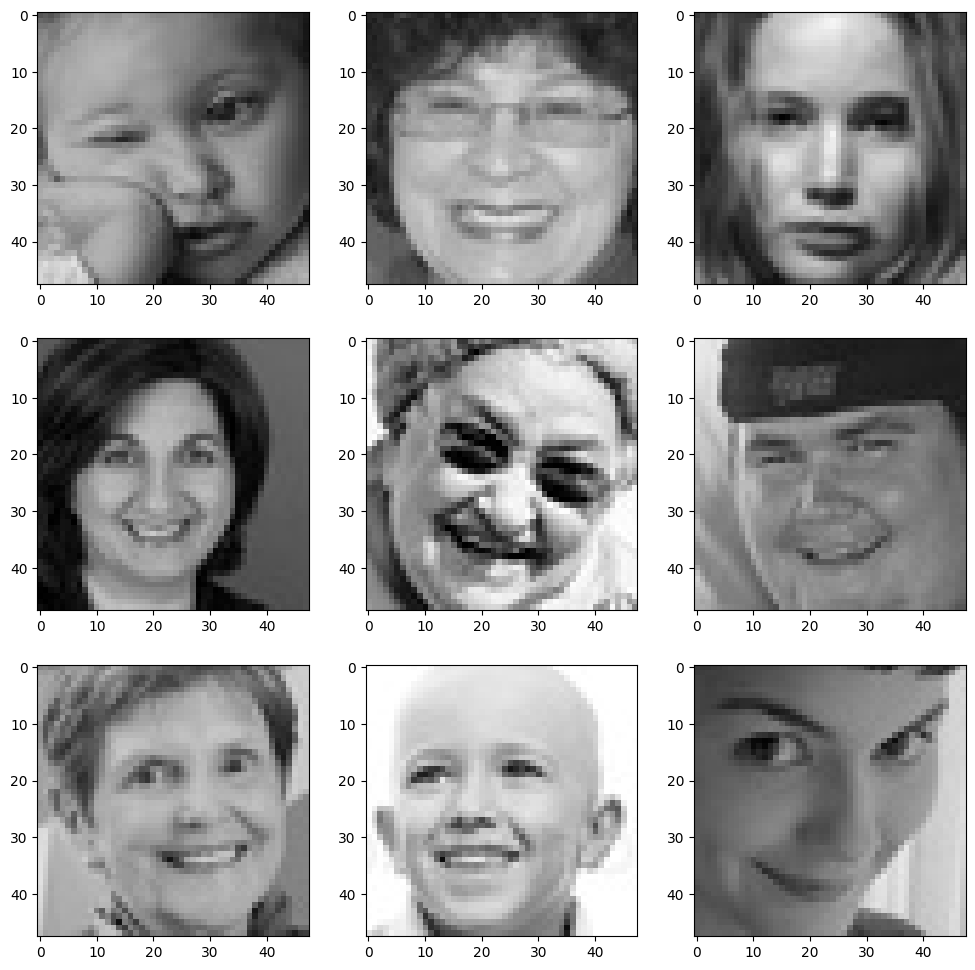

In [4]:
expression = 'confident'
plt.figure(figsize = (12, 12))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)
    img = load_img(folder_path + "/train/" + expression + "/" + os.listdir(folder_path + '/train/' + expression)[i],
                   target_size = (picture_size, picture_size))
    plt.imshow(img)
plt.show()

In [5]:
batch_size = 64
datagen_train = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   validation_split=0.2)

datagen_val = ImageDataGenerator(horizontal_flip=True)

train_set = datagen_train.flow_from_directory(folder_path + "/train",
                                          target_size = (picture_size, picture_size),
                                          color_mode = 'grayscale',
                                          batch_size = batch_size,
                                          class_mode = 'binary',
                                            subset = 'training',
                                          shuffle = True)

val_set = datagen_train.flow_from_directory(folder_path + "/train",
                                            target_size=(picture_size, picture_size),
                                            color_mode='grayscale',
                                            batch_size=batch_size,
                                            class_mode='binary',
                                            subset='validation',  # Dữ liệu cho tập validation
                                            shuffle=False)

test_set = datagen_train.flow_from_directory(folder_path + "/train",
                                           target_size = (picture_size, picture_size),
                                           color_mode = 'grayscale',
                                           batch_size = batch_size,
                                           class_mode = 'binary',
                                           shuffle = False)


Found 22967 images belonging to 2 classes.
Found 5740 images belonging to 2 classes.
Found 28707 images belonging to 2 classes.


In [6]:
from keras.optimizers import Adam, SGD, RMSprop
from keras.regularizers import l2
model = Sequential()

# 1 - Convolution layer
model.add(Conv2D(64,(3,3), padding='same', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 2nd Convolution layer
model.add(Conv2D(128,(5,5), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 3rd Convolution layer
model.add(Conv2D(512,(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 4th Convolution layer
model.add(Conv2D(512,(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flattening
model.add(Flatten())

# Fully connected layer 1st layer
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

# Fully connected layer 2nd layer
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(1, activation='sigmoid'))

opt = Adam(0.01)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 4,475,649 (17.07 MB)

 Trainable params: 4,471,681 (17.06 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [7]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint('./model.keras', monitor = 'val_acc', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                              min_delta = 0,
                              patience = 10,
                              verbose = 1,
                              restore_best_weights = True)
reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                                       factor = 0.2,
                                       patience = 3,
                                       verbose = 1,
                                       min_delta = 0.0001)
callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

In [8]:
%%time

epochs = 200

history = model.fit(
    train_set,
    epochs=epochs,
    validation_data = val_set,
    callbacks=callbacks_list
)

Epoch 1/200


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  1/359 ━━━━━━━━━━━━━━━━━━━━ 2:32:14 26s/step - accuracy: 0.5312 - loss: 0.8308

I0000 00:00:1746456928.492164     135 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1746456928.517299     135 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


188/359 ━━━━━━━━━━━━━━━━━━━━ 58s 339ms/step - accuracy: 0.5423 - loss: 0.8240

...

358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.5472 - loss: 0.7807

W0000 00:00:1746457034.413769     133 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


359/359 ━━━━━━━━━━━━━━━━━━━━ 157s 369ms/step - accuracy: 0.5473 - loss: 0.7804 - val_accuracy: 0.5740 - val_loss: 0.6931 - learning_rate: 0.0100
Epoch 2/200


W0000 00:00:1746457060.396982     133 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
/opt/conda/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_acc available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


359/359 ━━━━━━━━━━━━━━━━━━━━ 48s 131ms/step - accuracy: 0.5764 - loss: 0.6809 - val_accuracy: 0.4465 - val_loss: 0.7441 - learning_rate: 0.0100
Epoch 3/200
359/359 ━━━━━━━━━━━━━━━━━━━━ 48s 131ms/step - accuracy: 0.6055 - loss: 0.6609 - val_accuracy: 0.4282 - val_loss: 1.1920 - learning_rate: 0.0100
Epoch 4/200
359/359 ━━━━━━━━━━━━━━━━━━━━ 50s 137ms/step - accuracy: 0.6161 - loss: 0.6485 - val_accuracy: 0.5866 - val_loss: 0.6739 - learning_rate: 0.0100
Epoch 5/200
359/359 ━━━━━━━━━━━━━━━━━━━━ 55s 150ms/step - accuracy: 0.6520 - loss: 0.6235 - val_accuracy: 0.4406 - val_loss: 2.1399 - learning_rate: 0.0100
Epoch 6/200
359/359 ━━━━━━━━━━━━━━━━━━━━ 47s 129ms/step - accuracy: 0.6707 - loss: 0.6010 - val_accuracy: 0.5930 - val_loss: 0.7074 - learning_rate: 0.0100
Epoch 7/200
359/359 ━━━━━━━━━━━━━━━━━━━━ 45s 124ms/step - accuracy: 0.6909 - loss: 0.5775 - val_accuracy: 0.6690 - val_loss: 0.6040 - learning_rate: 0.0100
Epoch 8/200
359/359 ━━━━━━━━━━━━━━━━━━━━ 46s 126ms/step - accuracy: 0.7125 -

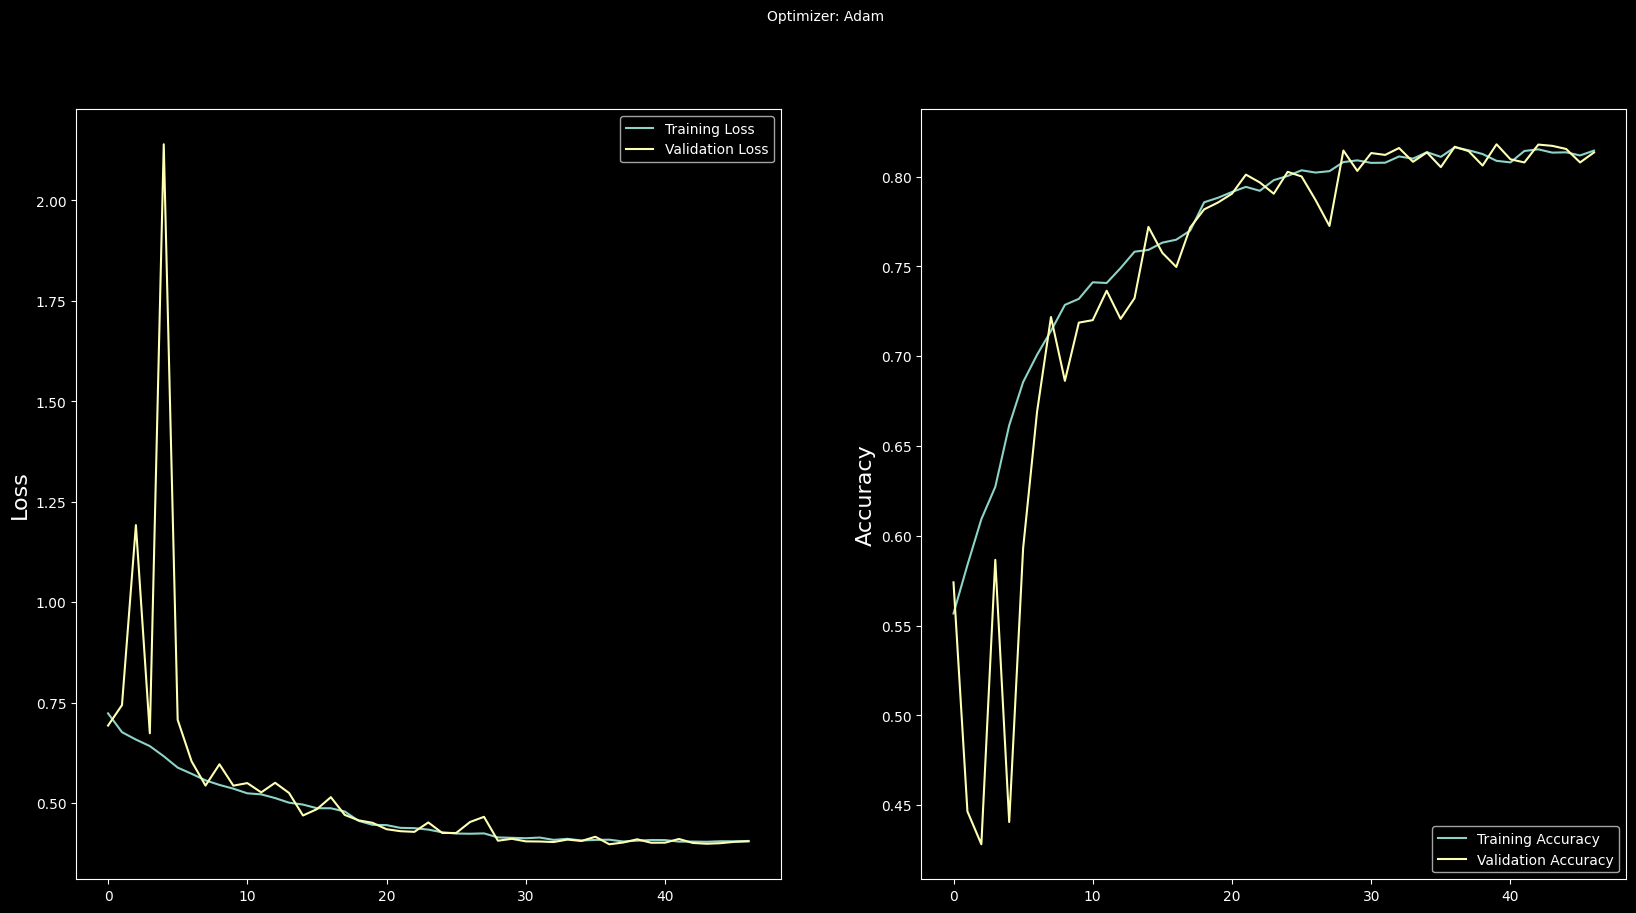

In [10]:
plt.style.use('dark_background')

plt.figure(figsize = (20, 10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer: Adam', fontsize = 10)
plt.ylabel('Loss', fontsize = 16)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.legend(loc = 'upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize = 16)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.show()

In [11]:
model.save('confidence_measuring_photo.h5')
model.save_weights('confidence_model_weights.weights.h5')

In [ ]:
test_loss, test_acc = model.evaluate(test_set, steps=len(test_set))

In [13]:
print(f'Test accuracy: {test_acc}')

Test accuracy: 0.8278120160102844


### Testing

In [3]:
import cv2
import numpy as np
import mediapipe as mp
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
from keras.models import load_model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


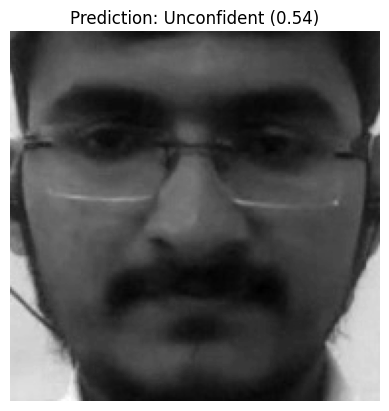

In [14]:
model = load_model('confidence_measuring_photo.h5')

image_path = '1025.jpg'
image = cv2.imread(image_path)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Initialize MediaPipe Face Detection
mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)

# Detect faces
results = face_detection.process(rgb_image)

if results.detections:
    # Find face with highest confidence
    best_detection = max(results.detections, key=lambda d: d.score[0])
    bbox = best_detection.location_data.relative_bounding_box

    h, w, _ = image.shape
    x, y = int(bbox.xmin * w), int(bbox.ymin * h)
    w_box, h_box = int(bbox.width * w), int(bbox.height * h)

    # Clip coordinates to image bounds
    x, y = max(x, 0), max(y, 0)
    x2, y2 = min(x + w_box, w), min(y + h_box, h)

    # Crop and preprocess
    face_crop = image[y:y2, x:x2]
    face_gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)
    face_resized = cv2.resize(face_gray, (48, 48))
    face_normalized = face_resized / 255.0
    face_input = np.expand_dims(face_normalized, axis=(0, -1))  # Shape: (1, 48, 48, 1)

    # Predict
    prediction = model.predict(face_input)
    label = "Unconfident" if prediction[0][0] > 0.5 else "Confident"

    # Display result
    plt.imshow(face_gray, cmap='gray')
    plt.title(f"Prediction: {label} ({prediction[0][0]:.2f})")
    plt.axis('off')
    plt.show()

else:
    print("No face detected in the image.")